# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_data.csv')
approved_df = (df['loan_status'] == 1)

pd.crosstab(df['person_age'], df['loan_status'])
pd.crosstab(df['person_gender'], df['loan_status'])


loan_status,0,1
person_gender,,
female,15934,1975
male,24173,2918


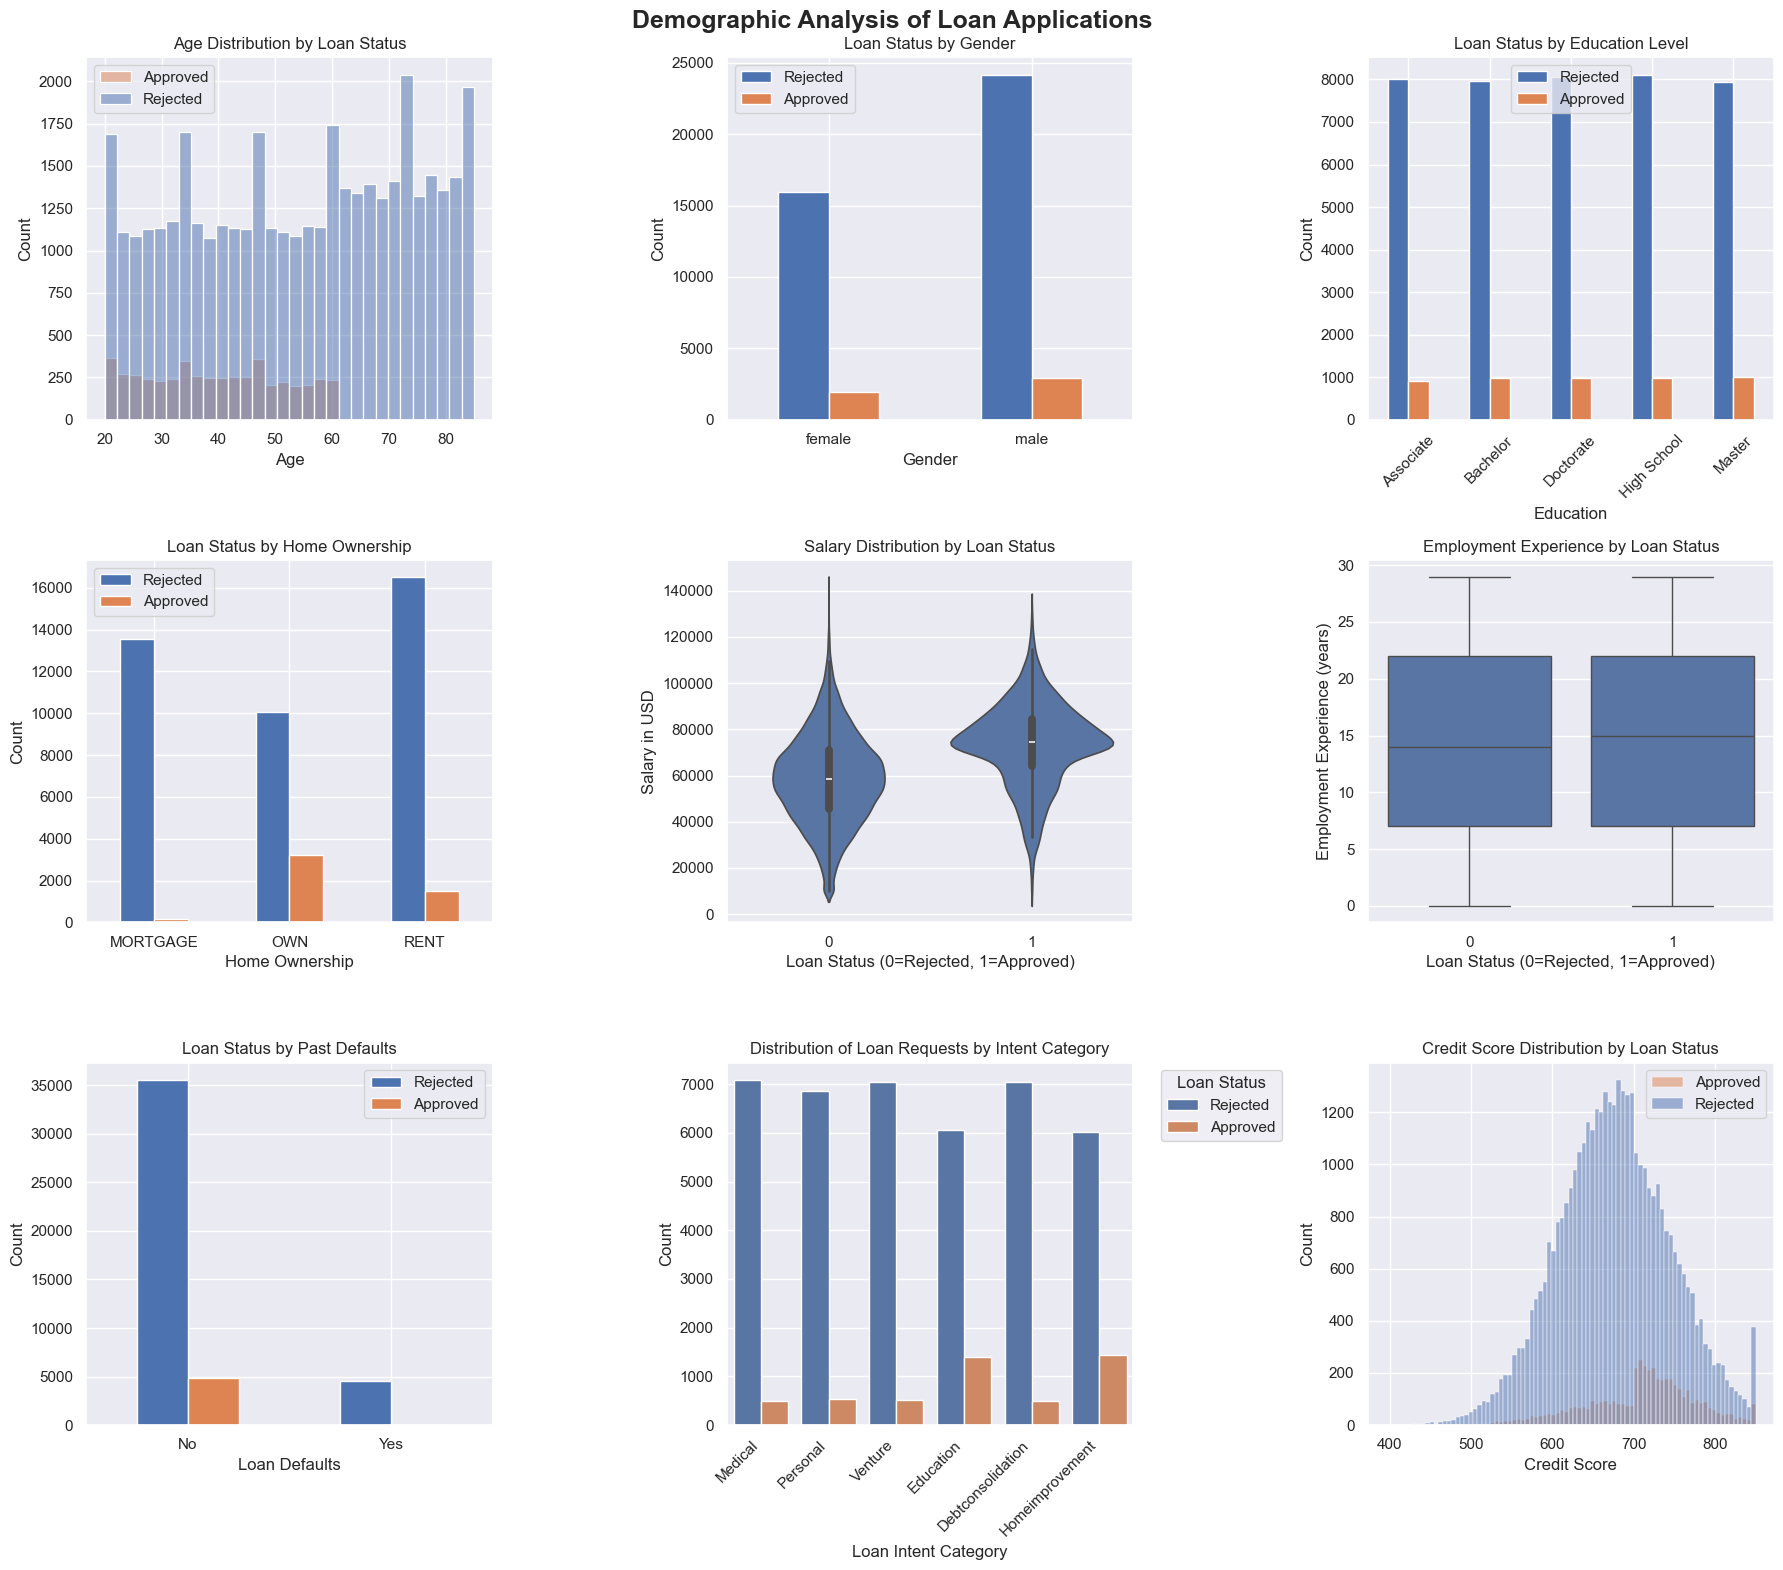

In [67]:

# Set up the figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('Demographic Analysis of Loan Applications', fontsize=18, fontweight='bold')
    
# 1. Age distribution
# Create a new column with string labels
df['loan_status_label'] = df['loan_status'].map({0: 'Rejected', 1: 'Approved'})

# Use the new column for plotting
sns.histplot(data=df, x='person_age', hue='loan_status', bins=30, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Loan Status')
axes[0,0].set_xlabel('Age')
axes[0,0].legend(['Approved', 'Rejected'])


# 2. Gender distribution
gender_counts = df.groupby(['person_gender', 'loan_status']).size().unstack()
gender_counts.plot(kind='bar', ax=axes[0,1], rot=0)
axes[0,1].set_title('Loan Status by Gender')
axes[0,1].set_xlabel('Gender')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(['Rejected', 'Approved'])
    
# 3. Education level
education_counts = df.groupby(['person_education', 'loan_status']).size().unstack()
education_counts.plot(kind='bar', ax=axes[0,2], rot=45)
axes[0,2].set_title('Loan Status by Education Level')
axes[0,2].set_xlabel('Education')
axes[0,2].set_ylabel('Count')
axes[0,2].legend(['Rejected', 'Approved'])
    
# 4. Home ownership
home_counts = df.groupby(['person_home_ownership', 'loan_status']).size().unstack()
home_counts.plot(kind='bar', ax=axes[1,0], rot=0)
axes[1,0].set_title('Loan Status by Home Ownership')
axes[1,0].set_xlabel('Home Ownership')
axes[1,0].set_ylabel('Count')
axes[1,0].legend(['Rejected', 'Approved'])
    
# 5. Salary Analysis
sns.violinplot(data=df, x='loan_status', y='person_income', ax=axes[1,1])
axes[1,1].set_title('Salary Distribution by Loan Status')
axes[1,1].set_xlabel('Loan Status (0=Rejected, 1=Approved)')
axes[1,1].set_ylabel('Salary in USD')

    
# 6. Employment experience
sns.boxplot(data=df, x='loan_status', y='person_emp_exp',ax=axes[1,2])
axes[1,2].set_title('Employment Experience by Loan Status')
axes[1,2].set_xlabel('Loan Status (0=Rejected, 1=Approved)')
axes[1,2].set_ylabel('Employment Experience (years)')

#7 Previous Loan Defaults On File
defaults_counts = df.groupby(['previous_loan_defaults_on_file', 'loan_status']).size().unstack()
defaults_counts.plot(kind='bar', ax=axes[2,0], rot=0)
axes[2,0].set_title('Loan Status by Past Defaults')
axes[2,0].set_xlabel('Loan Defaults')
axes[2,0].set_ylabel('Count')
axes[2,0].legend(['Rejected', 'Approved'])

#8 Seaborn Practice
# Trying to clean the catoegopry names
df['loan_intent_short'] = df['loan_intent'].str.replace('_', ' ').str.title()

# Create the plot
sns.countplot(data=df, x="loan_intent_short", hue="loan_status", ax=axes[2,1])

# Formatting
axes[2,1].set_title('Distribution of Loan Requests by Intent Category')
axes[2,1].set_xlabel('Loan Intent Category')
axes[2,1].set_ylabel('Count')
axes[2,1].legend(['Rejected', 'Approved'], title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left',)

# Rotate labels if categories have long names
plt.setp(axes[2,1].get_xticklabels(), rotation=45, ha='right')

#9 More Seaborn Practice
sns.histplot(data=df, x='credit_score', hue='loan_status_label', hue_order=['Rejected', 'Approved'], ax=axes[2,2])
axes[2,2].set_title('Credit Score Distribution by Loan Status')
axes[2,2].set_xlabel('Credit Score')
axes[2,2].legend(['Approved', 'Rejected'])
    
plt.tight_layout()
plt.show()





# Analysis
Based on my analysis of the loan data, it appears that the AI model used to approve these loans is heavily influenced by age, earning potential, and credit history. While the weights for credit history are reasonable, the AI model stops granting loans to individuals approximately over the age of 60. Gender appears to have a proportionate approval rates while it is very clear that the aproval rates drop to 0 after the previously stated age. This could very well put the company in legal trouble for age discrimination.